In [2]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Load the dataset
df = pd.read_csv('customer_churn.csv')

# Display basic info
print(df.shape)
print(df.columns)
print(df.head())

(10000, 14)
Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0        

In [3]:
# Drop unnecessary columns
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Encode categorical columns
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df['Geography'] = le.fit_transform(df['Geography'])

# Check missing values
print("Missing values:")
print(df.isnull().sum())
print("\nData after cleaning:")
print(df.head())

Missing values:
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Data after cleaning:
   CreditScore  Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0          619          0       0   42       2       0.00              1   
1          608          2       0   41       1   83807.86              1   
2          502          0       0   42       8  159660.80              3   
3          699          0       0   39       1       0.00              2   
4          850          2       0   43       2  125510.82              1   

   HasCrCard  IsActiveMember  EstimatedSalary  Exited  
0          1               1        101348.88       1  
1          0               1        112542.58       0  
2          1               0        113931.57       1  
3          0               0         

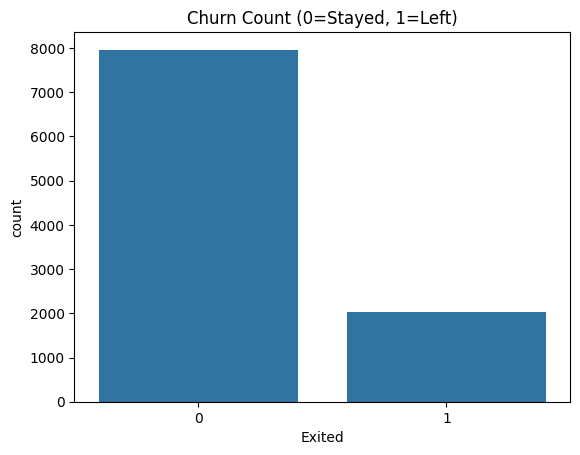

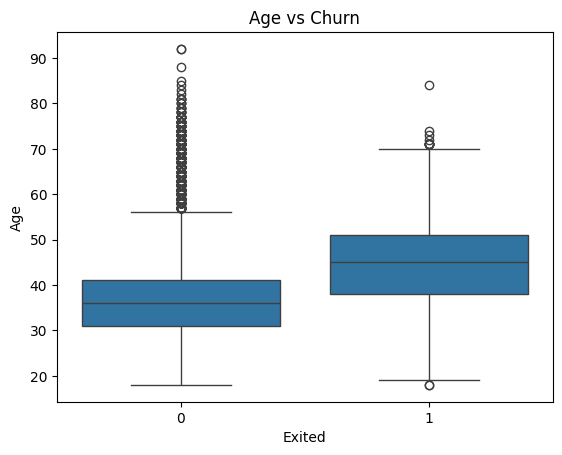

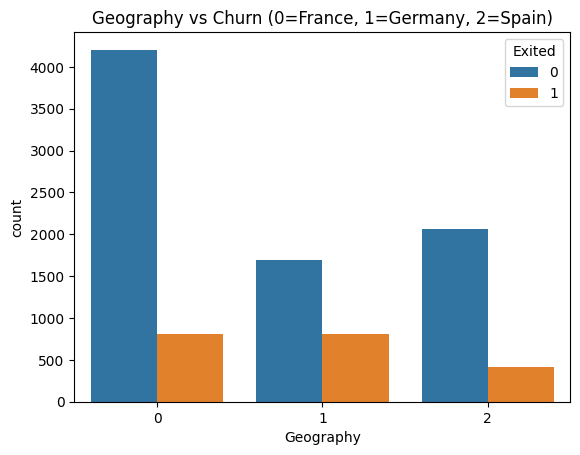

In [4]:
# Churn count
sns.countplot(data=df, x='Exited')
plt.title('Churn Count (0=Stayed, 1=Left)')
plt.show()

# Age vs Churn
sns.boxplot(data=df, x='Exited', y='Age')
plt.title('Age vs Churn')
plt.show()

# Geography vs Churn
sns.countplot(data=df, x='Geography', hue='Exited')
plt.title('Geography vs Churn (0=France, 1=Germany, 2=Spain)')
plt.show()

In [5]:
# Define features and target
X = df.drop('Exited', axis=1)
y = df['Exited']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Model Trained Successfully!")

Model Trained Successfully!


Accuracy: 0.8645


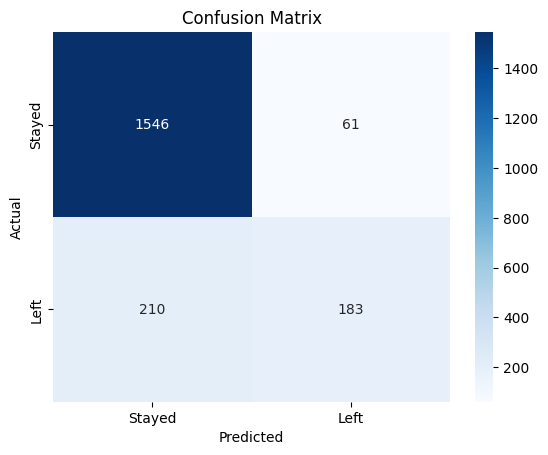

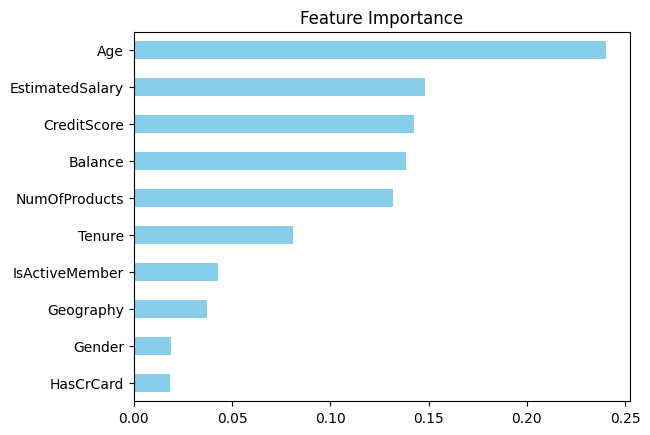

In [6]:
# Make predictions
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed','Left'],
            yticklabels=['Stayed','Left'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Feature Importance
feat_imp = pd.Series(model.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind='barh', color='skyblue')
plt.title('Feature Importance')
plt.show()

In [7]:
# Conclusion
print("""
Key Insights from Customer Churn Prediction:
1. Model Accuracy: {:.2f}%
2. Age is the most important factor for churn
3. Older customers (45+) are more likely to leave
4. Germany has the highest churn rate
5. Having a credit card has least impact on churn
""".format(accuracy_score(y_test, y_pred) * 100))


Key Insights from Customer Churn Prediction:
1. Model Accuracy: 86.45%
2. Age is the most important factor for churn
3. Older customers (45+) are more likely to leave
4. Germany has the highest churn rate
5. Having a credit card has least impact on churn

